### What this notebook does
1. Class distribution — how attacks compare to normal traffic
2. Protocol analysis — TCP, UDP, ICMP breakdown
3. Attack patterns — TCP payload sizes, land attacks
4. Service & flag analysis — top services and connection flags
5. Feature distributions — byte counts, duration
6. Correlation analysis — identifying highly related features
7. Binary target creation — `normal` vs `anomaly`

## Imports & Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

print("Libraries imported")

Libraries imported


## Load Data

In [25]:
DATA_PATH = os.path.join("data", "labeled_dataset.csv")
df = pd.read_csv(DATA_PATH)

# Create binary target for anomaly vs normal
df["binary_target"] = df["class"].apply(lambda x: "normal" if x == "normal" else "anomaly")

print(f"Dataset loaded: {df.shape[0]}")
df.head()

Dataset loaded: 125973


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty_level,binary_target
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21,normal


## Class Distribution

How many unique attack types are there, and how does traffic split between normal and anomalous?

In [26]:
print(f"Unique traffic classes : {df['class'].nunique()}")
print("\nTop 10 classes by count:")
print(df["class"].value_counts().head(10))

Unique traffic classes : 23

Top 10 classes by count:
class
normal         67343
neptune        41214
satan           3633
ipsweep         3599
portsweep       2931
smurf           2646
nmap            1493
back             956
teardrop         892
warezclient      890
Name: count, dtype: int64


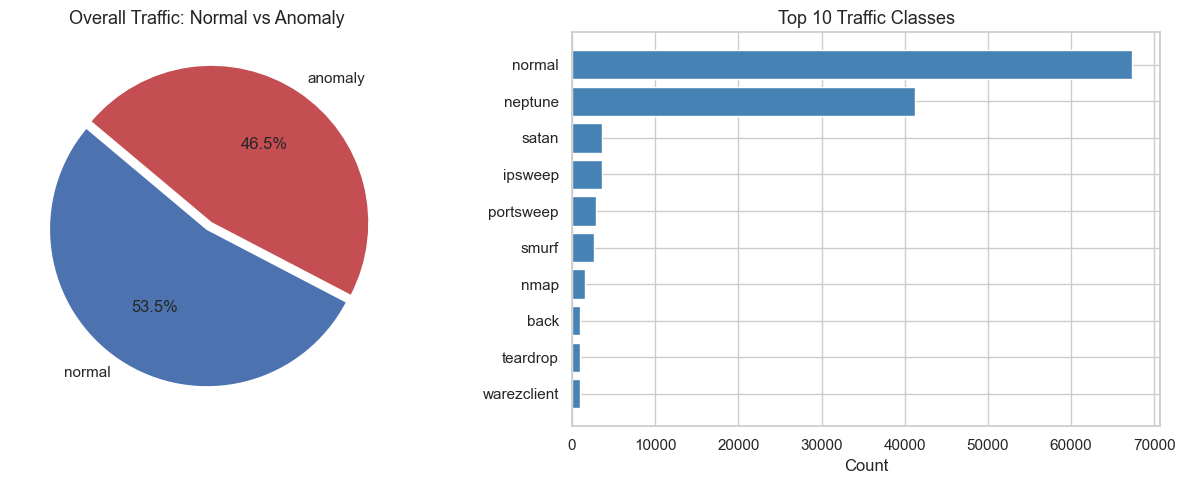

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Checks between normal vs anomaly
target_counts = df["binary_target"].value_counts()
axes[0].pie(
    target_counts,
    labels=target_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=["#4C72B0", "#C44E52"],
    explode=(0, 0.05),
)
axes[0].set_title("Overall Traffic: Normal vs Anomaly", fontsize=13)

# Top 10 attack classes
top_classes = df["class"].value_counts().head(10)
axes[1].barh(top_classes.index[::-1], top_classes.values[::-1], color="steelblue")
axes[1].set_xlabel("Count")
axes[1].set_title("Top 10 Traffic Classes", fontsize=13)

plt.tight_layout()
plt.show()

## Protocol

How is traffic distributed across different protocols?

In [28]:
print("Protocol distribution:")
print(df["protocol_type"].value_counts())

print("\nAverage connection duration by protocol (seconds):")
print(df.groupby("protocol_type")["duration"].mean())

Protocol distribution:
protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64

Average connection duration by protocol (seconds):
protocol_type
icmp      0.000000
tcp     281.386419
udp     485.372040
Name: duration, dtype: float64


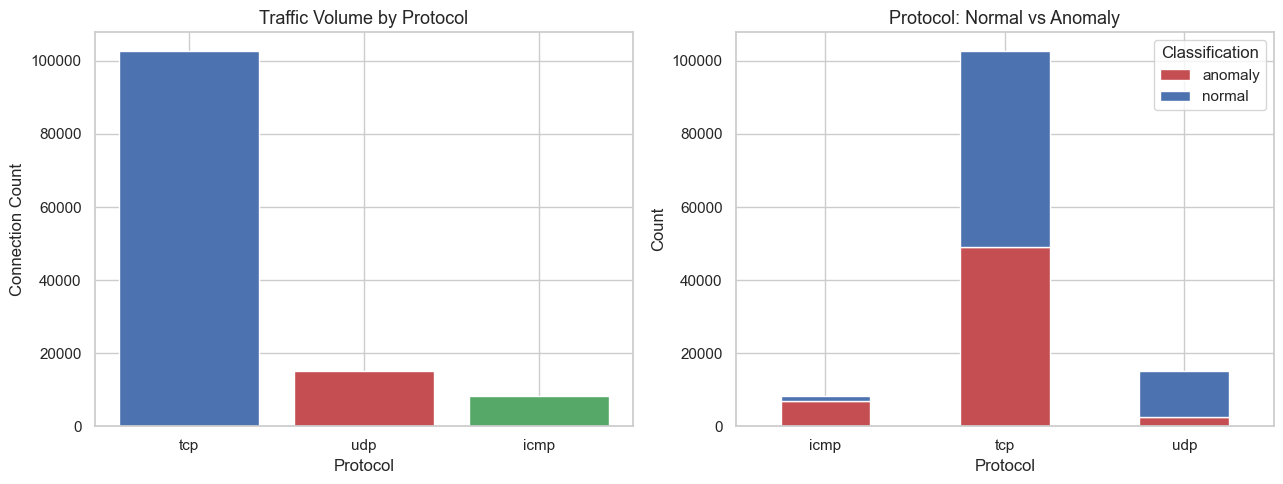

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Frequency of different Protocols
protocol_counts = df["protocol_type"].value_counts()
axes[0].bar(protocol_counts.index, protocol_counts.values, color=["#4C72B0", "#C44E52", "#55A868"], edgecolor="white")
axes[0].set_title("Traffic Volume by Protocol", fontsize=13)
axes[0].set_xlabel("Protocol")
axes[0].set_ylabel("Connection Count")

# See with Anomaly and Normal
protocol_dist = pd.crosstab(df["protocol_type"], df["binary_target"])
protocol_dist.plot(kind="bar", stacked=True, ax=axes[1], color=["#C44E52", "#4C72B0"], edgecolor="white")
axes[1].set_title("Protocol: Normal vs Anomaly", fontsize=13)
axes[1].set_xlabel("Protocol")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Classification")

plt.tight_layout()
plt.show()

## 5. Attack Pattern Analysis

### 5a. Do attacks use TCP with large payloads?

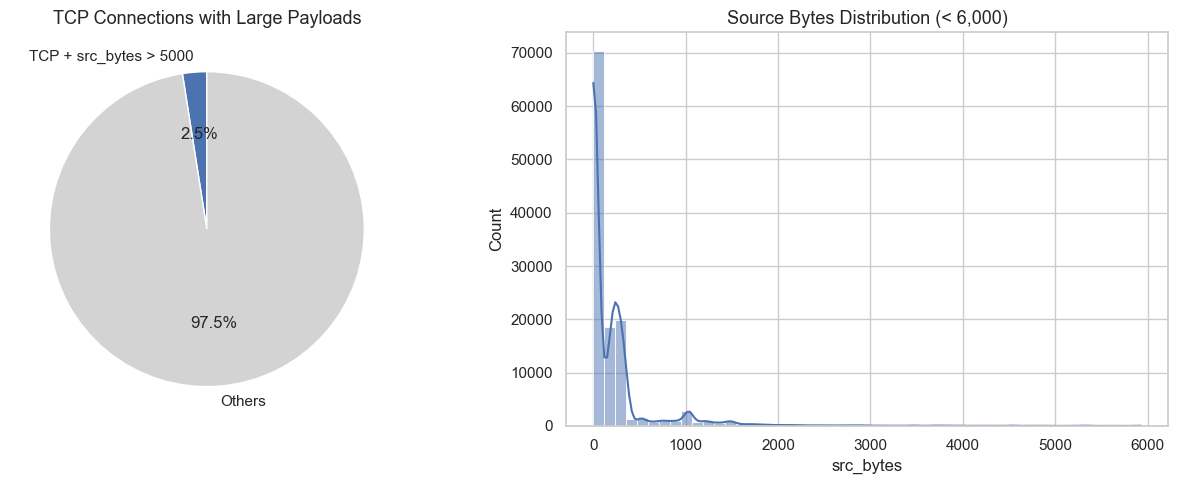

In [7]:
condition = (df["protocol_type"] == "tcp") & (df["src_bytes"] > 5000)
counts = [condition.sum(), (~condition).sum()]
labels = ["TCP + src_bytes > 5000", "Others"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: pie
axes[0].pie(counts, labels=labels, autopct="%1.1f%%", startangle=90, colors=["#4C72B0", "#D3D3D3"])
axes[0].set_title("TCP Connections with Large Payloads", fontsize=13)

# Right: src_bytes distribution (filtered)
small = df[df["src_bytes"] < 6000]
sns.histplot(small["src_bytes"], bins=50, kde=True, ax=axes[1], color="#4C72B0")
axes[1].set_title("Source Bytes Distribution (< 6,000)", fontsize=13)
axes[1].set_xlabel("src_bytes")

plt.tight_layout()
plt.show()

### 5b. Land Attack Detection

In [8]:
land_attacks = df["land"].sum()
print(f"Land attacks detected : {land_attacks:,}")
print(f"Non-land connections  : {len(df) - land_attacks:,}")
print(f"Land attack rate      : {land_attacks / len(df) * 100:.4f}%")

Land attacks detected : 25
Non-land connections  : 125,948
Land attack rate      : 0.0198%


## 5c. Attack Category Deep-Dive

Breaking down DoS, Probe, R2L, and U2R attack families to understand their traffic signatures.

In [9]:
ATTACK_MAPPING = {
    'normal':'normal',
    'back':'DoS','land':'DoS','neptune':'DoS','pod':'DoS','smurf':'DoS',
    'teardrop':'DoS','mailbomb':'DoS','apache2':'DoS','processtable':'DoS','udpstorm':'DoS',
    'satan':'Probe','ipsweep':'Probe','nmap':'Probe','portsweep':'Probe','mscan':'Probe','saint':'Probe',
    'guess_passwd':'R2L','ftp_write':'R2L','imap':'R2L','phf':'R2L','multihop':'R2L',
    'warezmaster':'R2L','warezclient':'R2L','spy':'R2L','xlock':'R2L','xsnoop':'R2L',
    'snmpguess':'R2L','snmpgetattack':'R2L','httptunnel':'R2L','sendmail':'R2L','named':'R2L',
    'buffer_overflow':'U2R','loadmodule':'U2R','perl':'U2R','rootkit':'U2R',
    'ps':'U2R','xterm':'U2R','sqlattack':'U2R',
}
df['attack_category'] = df['class'].map(lambda x: ATTACK_MAPPING.get(x, 'other'))

cat_stats = df.groupby('attack_category').agg(
    count        = ('class','size'),
    avg_duration = ('duration','mean'),
    avg_src_bytes= ('src_bytes','mean'),
    avg_dst_bytes= ('dst_bytes','mean'),
    logged_in_rate=('logged_in','mean'),
).round(2)
print('Attack Category Statistics:')
cat_stats

Attack Category Statistics:


,count,avg_duration,avg_src_bytes,avg_dst_bytes,logged_in_rate
attack_category,,,,,
DoS,45927,0.01,1176.32,169.20,0.02
Probe,11656,2074.86,385679.84,181074.91,0.01
R2L,995,633.42,307727.30,81822.03,0.91
U2R,52,80.94,906.23,5141.96,0.88
normal,67343,168.59,13133.28,4329.69,0.71


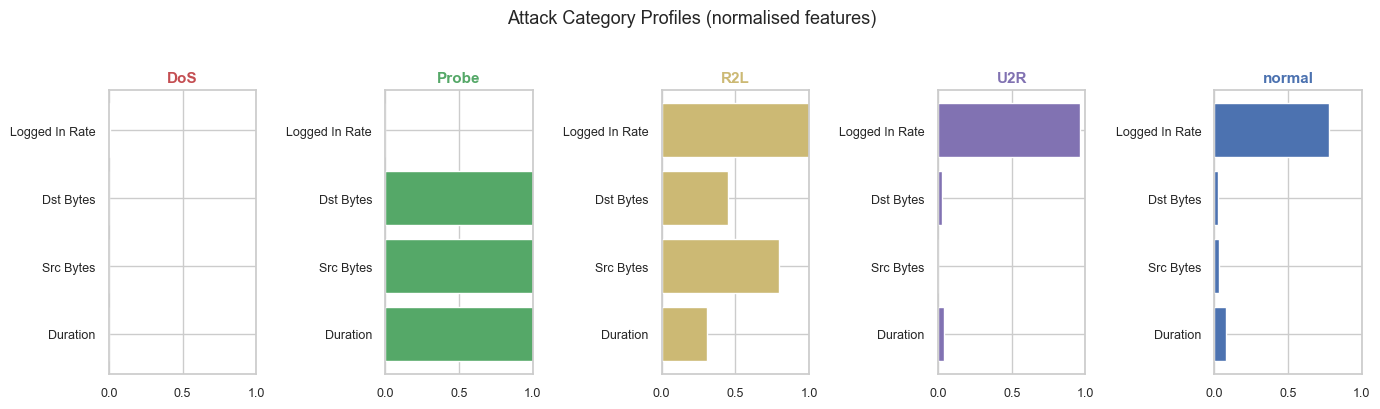

In [10]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

categories = ['avg_duration', 'avg_src_bytes', 'avg_dst_bytes', 'logged_in_rate']
labels     = ['Duration', 'Src Bytes', 'Dst Bytes', 'Logged In Rate']

# Normalize Radar
radar_df = cat_stats[categories].copy()
radar_df = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min() + 1e-9)

fig, axes = plt.subplots(1, len(radar_df), figsize=(14, 4))
colors = {'normal':'#4C72B0','DoS':'#C44E52','Probe':'#55A868','R2L':'#CCB974','U2R':'#8172B2','other':'#aaa'}

for ax, (cat, row) in zip(axes, radar_df.iterrows()):
    vals = row.values
    ax.barh(labels, vals, color=colors.get(cat, '#aaa'), edgecolor='white')
    ax.set_xlim(0, 1)
    ax.set_title(cat, fontsize=11, fontweight='bold', color=colors.get(cat, '#333'))
    ax.tick_params(labelsize=9)

plt.suptitle('Attack Category Profiles (normalised features)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 6. Service & Flag Analysis

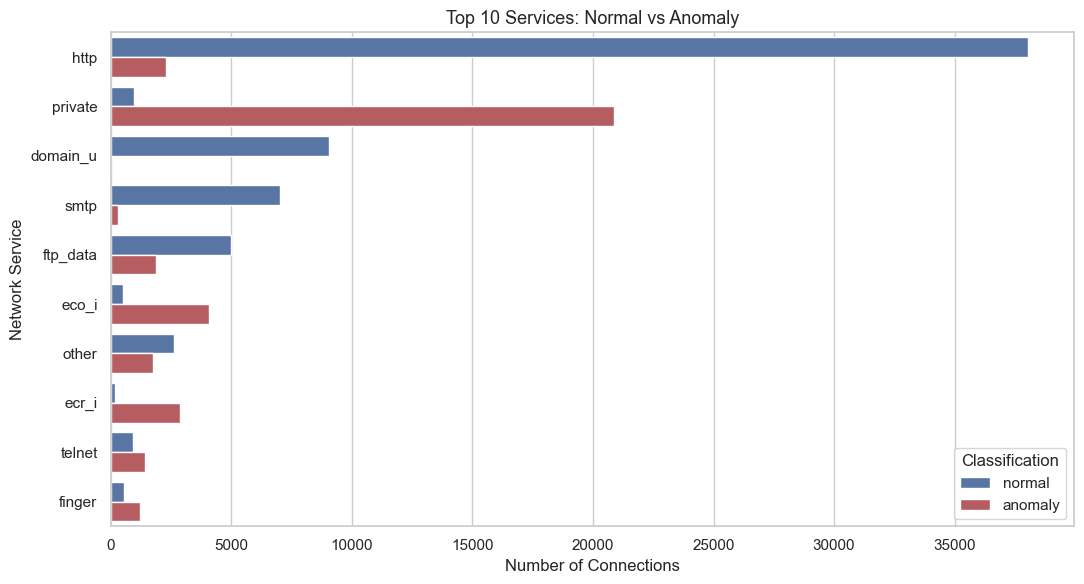

In [11]:
# Top 10 services: normal vs anomaly
top_10_services = df["service"].value_counts().head(10).index
df_top = df[df["service"].isin(top_10_services)]

plt.figure(figsize=(11, 6))
sns.countplot(
    y="service", hue="binary_target", data=df_top,
    order=top_10_services, palette=["#4C72B0", "#C44E52"]
)
plt.title("Top 10 Services: Normal vs Anomaly", fontsize=13)
plt.xlabel("Number of Connections")
plt.ylabel("Network Service")
plt.legend(title="Classification")
plt.tight_layout()
plt.show()

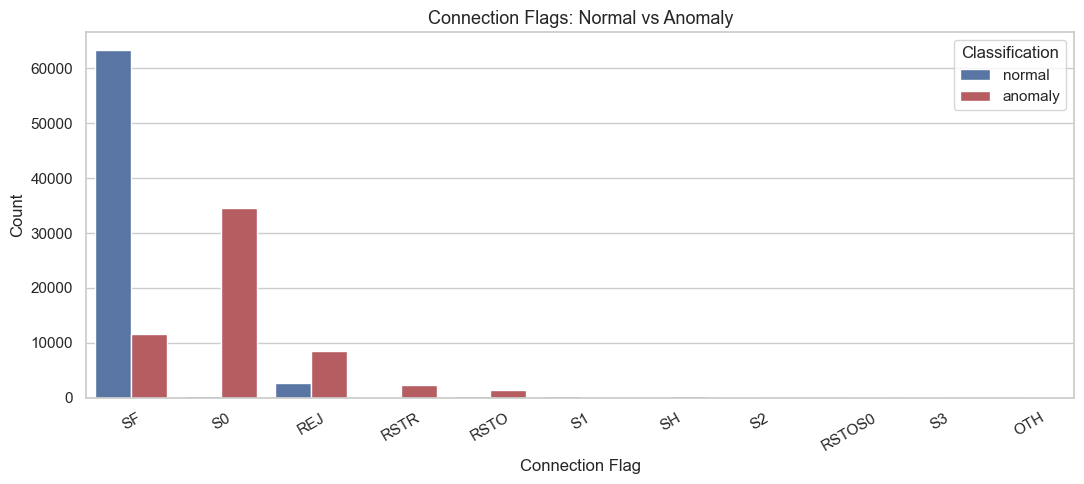

In [12]:
# Connection flags vs normal/anomaly
flag_order = df["flag"].value_counts().index

plt.figure(figsize=(11, 5))
sns.countplot(
    x="flag", hue="binary_target", data=df,
    order=flag_order, palette=["#4C72B0", "#C44E52"]
)
plt.title("Connection Flags: Normal vs Anomaly", fontsize=13)
plt.xlabel("Connection Flag")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.legend(title="Classification")
plt.tight_layout()
plt.show()

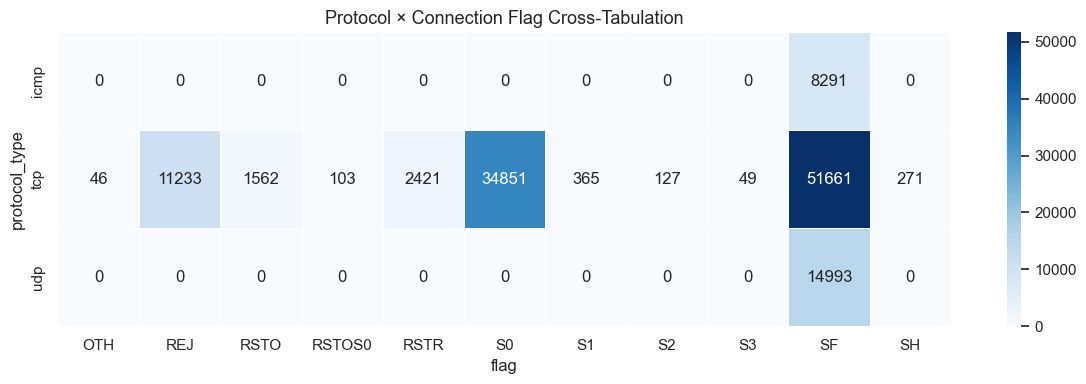

In [13]:
# Protocol and Flags crossvalidation
ct = pd.crosstab(df["protocol_type"], df["flag"])

plt.figure(figsize=(12, 4))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.title("Protocol × Connection Flag Cross-Tabulation", fontsize=13)
plt.tight_layout()
plt.show()

## Feature Distributions & Transformations

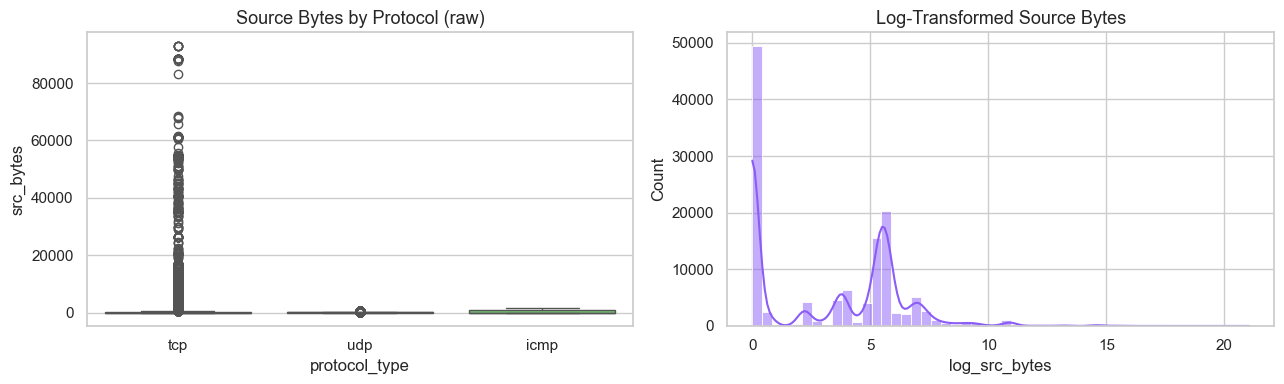

In [14]:
# src_bytes is heavily right-skewed — log transform improves visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

small = df[df["src_bytes"] < 100_000]
sns.boxplot(x="protocol_type", y="src_bytes", data=small, ax=axes[0], palette="muted")
axes[0].set_title("Source Bytes by Protocol (raw)", fontsize=13)

df["log_src_bytes"] = np.log1p(df["src_bytes"])
sns.histplot(df["log_src_bytes"], bins=50, kde=True, ax=axes[1], color="#8B5CF6")
axes[1].set_title("Log-Transformed Source Bytes", fontsize=13)

plt.tight_layout()
plt.show()

# Clean up temporary column
df.drop(columns=["log_src_bytes"], inplace=True)

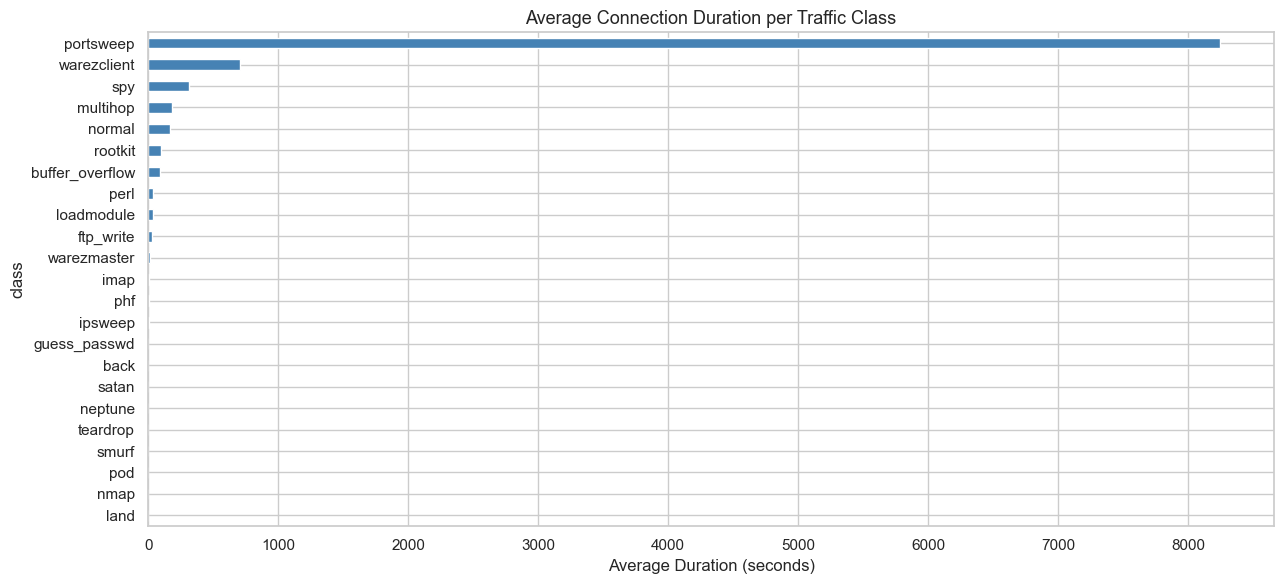

In [15]:
# Average connection duration per attack class
avg_duration = df.groupby("class")["duration"].mean().sort_values(ascending=True)

plt.figure(figsize=(13, 6))
avg_duration.plot(kind="barh", color="steelblue")
plt.title("Average Connection Duration per Traffic Class", fontsize=13)
plt.xlabel("Average Duration (seconds)")
plt.tight_layout()
plt.show()

## 8. Correlation Analysis

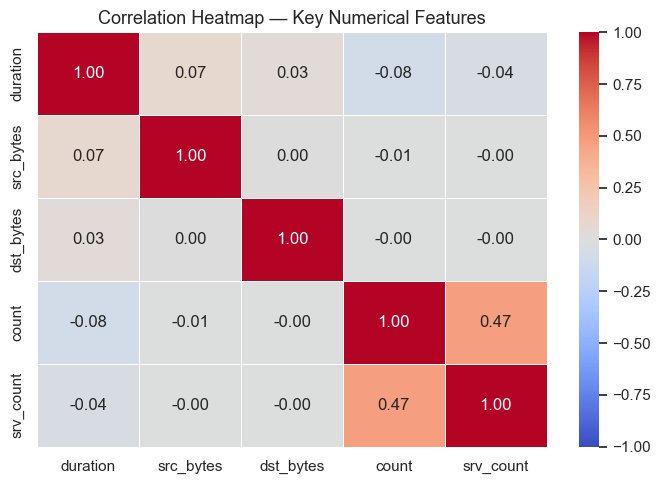

In [16]:
# Selected features correlation heatmap
key_cols = ["duration", "src_bytes", "dst_bytes", "count", "srv_count"]
corr = df[key_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Heatmap — Key Numerical Features", fontsize=13)
plt.tight_layout()
plt.show()

In [17]:
# Top 15 most correlated feature pairs
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=["difficulty_level"], errors="ignore")
corr_matrix  = numeric_cols.corr().abs()

upper_idx = np.triu_indices_from(corr_matrix, k=1)
pairs = [
    {"Feature 1": corr_matrix.columns[i], "Feature 2": corr_matrix.columns[j],
     "Correlation": corr_matrix.iloc[i, j]}
    for i, j in zip(*upper_idx)
]
corr_df = pd.DataFrame(pairs).sort_values("Correlation", ascending=False).dropna()

print("Top 15 Most Correlated Feature Pairs")
print("─" * 52)
print(corr_df.head(15).to_string(index=False))

Top 15 Most Correlated Feature Pairs
────────────────────────────────────────────────────
           Feature 1                Feature 2  Correlation
     num_compromised                 num_root     0.998833
         serror_rate          srv_serror_rate     0.993289
         rerror_rate          srv_rerror_rate     0.989008
     srv_serror_rate dst_host_srv_serror_rate     0.986252
dst_host_serror_rate dst_host_srv_serror_rate     0.985052
         serror_rate dst_host_srv_serror_rate     0.981139
         serror_rate     dst_host_serror_rate     0.979373
     srv_serror_rate     dst_host_serror_rate     0.977596
     srv_rerror_rate dst_host_srv_rerror_rate     0.970208
         rerror_rate dst_host_srv_rerror_rate     0.964449
         rerror_rate     dst_host_rerror_rate     0.926749
dst_host_rerror_rate dst_host_srv_rerror_rate     0.924688
     srv_rerror_rate     dst_host_rerror_rate     0.917822
  dst_host_srv_count   dst_host_same_srv_rate     0.896663
                 hot     

## Univariate Outlier Summary

Boxplots for the top skewed features, showing how outlier density differs between normal and anomaly traffic.

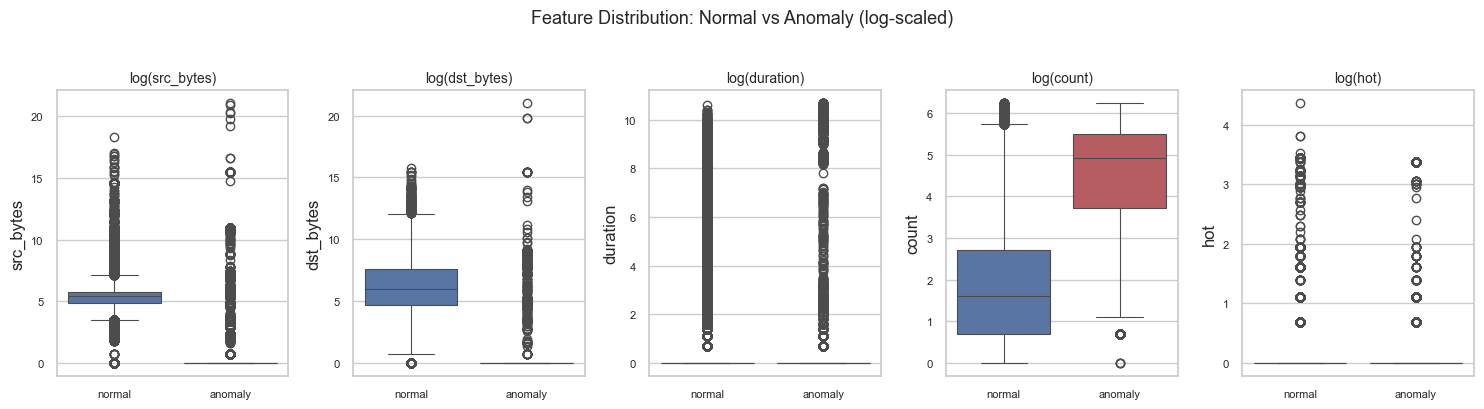

In [19]:
skew_features = ['src_bytes', 'dst_bytes', 'duration', 'count', 'hot']

fig, axes = plt.subplots(1, len(skew_features), figsize=(15, 4))
for ax, feat in zip(axes, skew_features):
    # Log scale to handle extreme values
    data = df[[feat, 'binary_target']].copy()
    data[feat] = np.log1p(data[feat])
    sns.boxplot(x='binary_target', y=feat, data=data,
                palette=['#4C72B0','#C44E52'], ax=ax, linewidth=0.8)
    ax.set_title(f'log({feat})', fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(labelsize=8)

plt.suptitle('Feature Distribution: Normal vs Anomaly (log-scaled)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

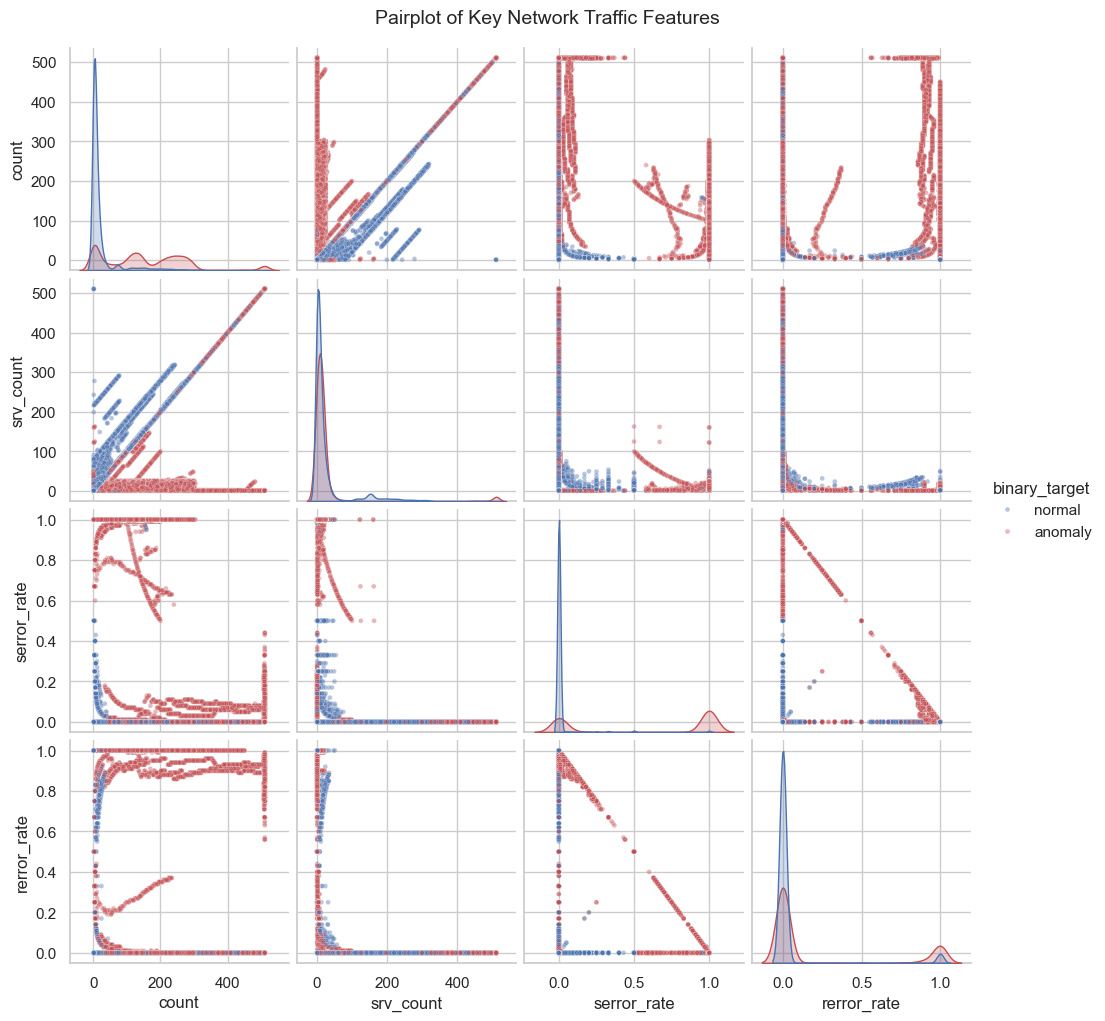

In [20]:
features_to_plot = ["count", "srv_count", "serror_rate", "rerror_rate", "binary_target"]
subset = df[features_to_plot]

sns.pairplot(subset, hue="binary_target", palette=["#4C72B0", "#C44E52"],
             plot_kws={"alpha": 0.4, "s": 12})
plt.suptitle("Pairplot of Key Network Traffic Features", y=1.02, fontsize=14)
plt.show()

### Findings

| Observation | Implication |
|-------------|-------------|
| `neptune` dominates the attack classes | Heavy class imbalance — SMOTE needed |
| `src_bytes` and `dst_bytes` are highly right-skewed | Log transformation required |
| Some rate features are highly correlated (> 0.95) | Dimensionality reduction possible |
| `SF` flag dominates normal traffic; `S0` dominates attacks | `flag` is a strong predictor |
| ICMP traffic is almost entirely anomalous | Protocol is a strong signal |